# 09 — Patch Sampling Analysis

**QUESTION:** If I sample patches randomly, what fraction contain active neurons?
Is that fraction dangerously low?

**DECISION:** 
- > 20% active → random sampling fine
- < 5% active → must use stratified/weighted sampling
- 5-20% → borderline, consider smart sampler

In [9]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from load_data import load_f1_stack
from sampling import get_activity_threshold, sample_random_patches, classify_patches
from smart_sampler import smart_patch_sampler, evaluate_sampler
from plots import plot_activity_histogram, plot_sample_patches
from analysis import print_decision, print_sampler_comparison, print_summary

DATA = Path("../../data/val")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load stack and compute activity

In [10]:
F1, activity = load_f1_stack(DATA)

F1 shape: (1500, 490, 490)
Activity map shape: (490, 490)
Activity range: [2353.66, 13626763.00]


## Activity threshold analysis

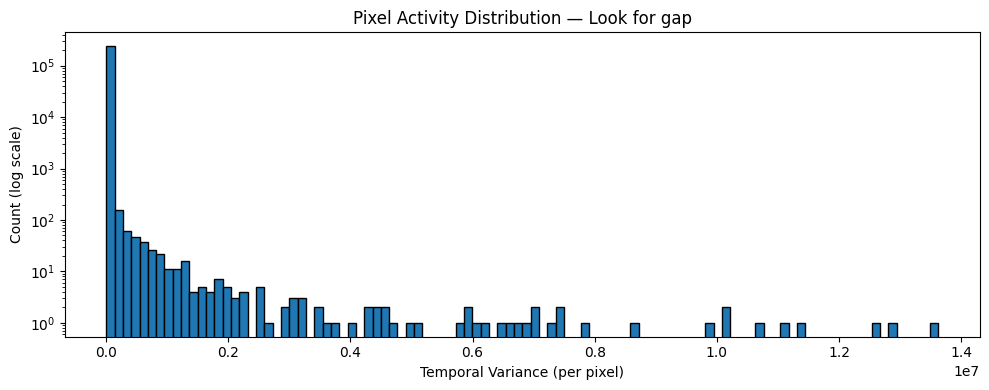

Threshold (75th percentile): 9893.42
Active pixels (> threshold): 60025 / 240100
Active pixel ratio: 25.00%


In [11]:
plot_activity_histogram(activity)
threshold = get_activity_threshold(activity, percentile=75)

## Random patch sampling

In [12]:
patches, patch_max_variances, patch_centers = sample_random_patches(
    F1, n_patches=1000, patch_size=(64, 128, 128)
)

Patch size: (64, 128, 128)
Sampling 1000 random patches...

Sampled 1000 patches
Max variance per patch: [15785.89, 43413836.00]


## Classify patches and make decision

In [13]:
n_active, n_background, active_ratio = classify_patches(patch_max_variances, threshold)
active_mask = patch_max_variances > threshold
print_decision(active_ratio)


PATCH CLASSIFICATION RESULTS

Threshold: 9893.42
Active patches (max_var > threshold): 1000 / 1000
Background patches (max_var ≤ threshold): 0 / 1000

Active patch ratio: 100.00%

DECISION
✓ 100.0% active → RANDOM SAMPLING FINE
  Enough signal in random patches



## Visualize sample patches

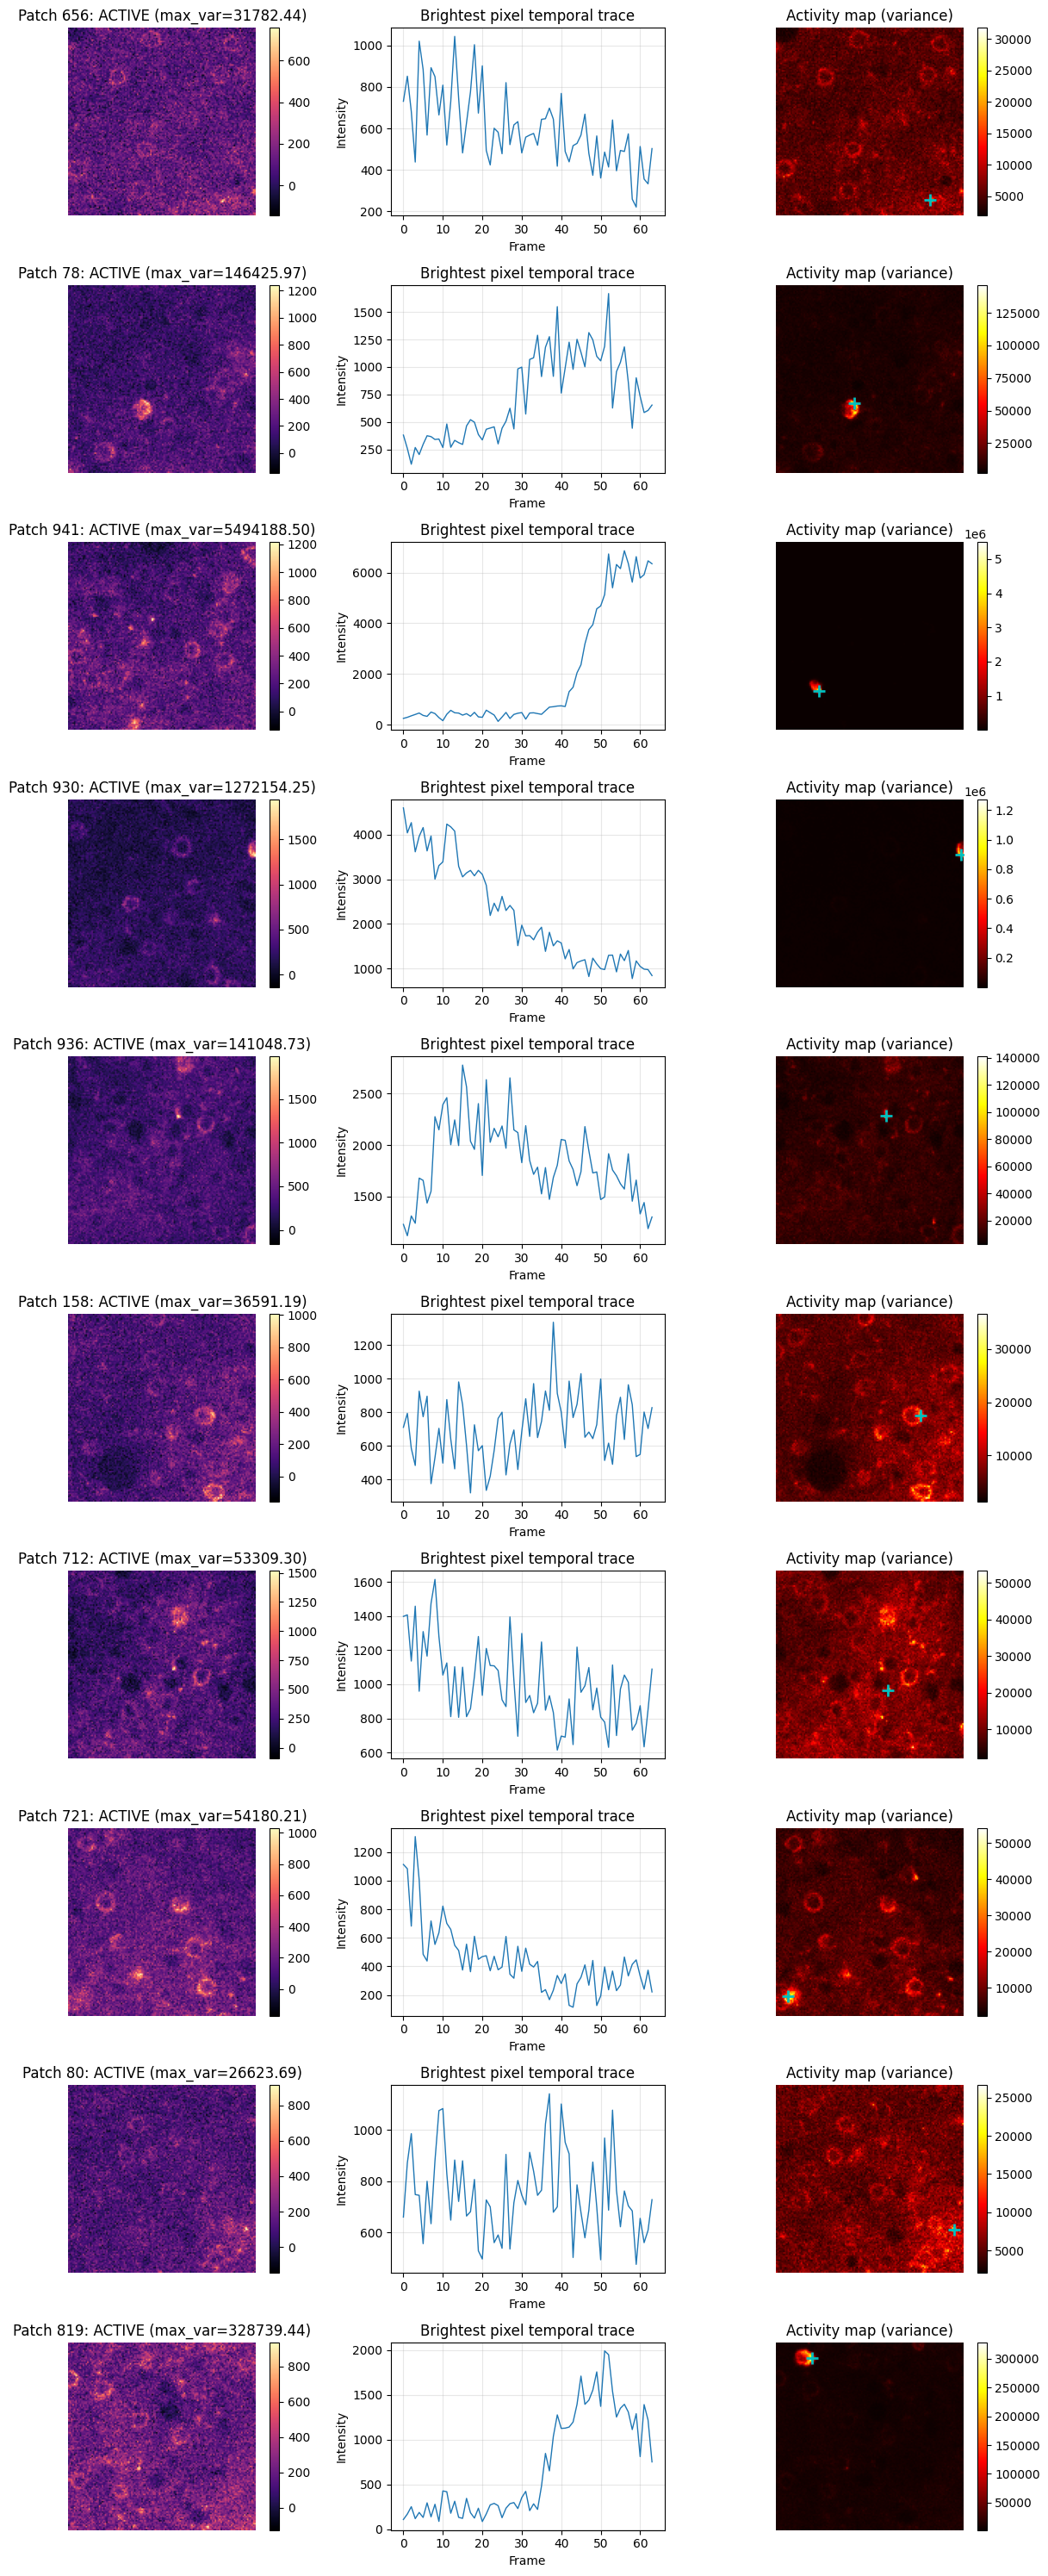

✓ Visualized 10 random patches


In [14]:
plot_sample_patches(
    patches,
    patch_max_variances,
    active_mask,
    threshold,
    n_viz=10,
    save_path="/tmp/sample_patches.png"
)

## Smart sampler evaluation (if needed)

In [15]:
if active_ratio < 20:
    print(f"\n" + "="*80)
    print("SMART PATCH SAMPLER IMPLEMENTATION")
    print("="*80 + "\n")
    
    smart_patches, smart_centers = smart_patch_sampler(
        F1, n_patches=100,
        activity_threshold=threshold,
        active_bias=0.8
    )
    
    n_smart_active, smart_ratio = evaluate_sampler(smart_patches, threshold)
    print(f"\nSmart sampler results:")
    print(f"Active patches: {n_smart_active} / {len(smart_patches)}")
    print(f"Active ratio: {smart_ratio:.2f}%")
    
    print_sampler_comparison(active_ratio, smart_ratio)
    print("\n✓ Smart sampler implementation ready")
    print("  Use this in training to guarantee 80% of batches contain neurons")
else:
    print(f"\n✓ Random sampling sufficient ({active_ratio:.1f}% active)")
    print("  No need for smart sampler")


✓ Random sampling sufficient (100.0% active)
  No need for smart sampler


## Summary

In [16]:
print_summary(active_ratio)


SUMMARY

Random sampling: 100.00% active patches

If using random sampling:
  - 0.0% of batches are background
  - Model wastes compute learning empty regions

If using smart sampler (80% active):
  - 80% of batches guaranteed to have neurons
  - 20% still see background (keeps model honest)
  - Much more efficient training

